In [ ]:
##XGBOOST MODEL With Target Variable as Snow

In [1]:
!pip install xgboost
!pip install scikit-learn

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt

df = pd.read_csv("C:/Users/Gokul Shrivastav/Downloads/Wiarton_Airport_2019-2025 (1)(in).csv")
df.head()


,date,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun
0,1/1/2019,-6.5,-13.4,0.4,2.2,40.0,353.0,11.7,48.0,1018.7,NaN
1,1/2/2019,-8.8,-15.9,-1.6,3.6,40.0,138.0,10.7,NaN,1022.1,NaN
2,1/3/2019,-0.6,-2.5,1.3,0.0,100.0,242.0,21.7,58.0,1011.2,NaN
3,1/4/2019,1.3,-0.7,3.2,0.0,80.0,230.0,18.9,46.0,1006.3,NaN
4,1/5/2019,1.7,-0.2,3.5,0.0,40.0,262.0,10.3,37.0,1006.0,NaN


In [3]:
##Dropping Rows
df_clean = df.dropna(subset=['snow'])

##Dropping non-feature columns
features = df_clean.drop(columns=['date', 'snow', 'tsun'])
target = df_clean['snow']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((389, 8), (98, 8))

In [5]:
##XGBoost Regressor
model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [7]:
##Make predictions and evaluate the model
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Squared Error: 25328.55
R² Score: 0.06


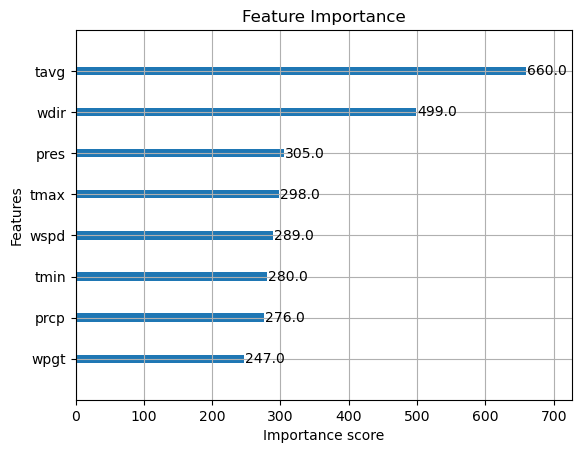

In [9]:
##Plot feature importance
xgb.plot_importance(model)
plt.title('Feature Importance')
plt.show()

In [ ]:
##Hyperameter tuning

In [11]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

In [13]:
param_dist = {
    "n_estimators": [50, 100, 200, 300],
    "max_depth": [3, 4, 5, 6, 7, 8],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.2, 0.4],
    "reg_alpha": [0, 0.01, 0.1],
    "reg_lambda": [1, 1.5, 2.0]
}

##Initialize the XGBoost Regressor
xgb_model = xgb.XGBRegressor(random_state=42)

##Randoom Grid Search 
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=30,  
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)
##Run the search
random_search.fit(X_train, y_train)

print("Best parameters found:", random_search.best_params_)
print("Best RMSE:", np.sqrt(-random_search.best_score_))

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best parameters found: {'subsample': 0.8, 'reg_lambda': 1.5, 'reg_alpha': 0.01, 'n_estimators': 50, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.6}
Best RMSE: 115.20352589096052


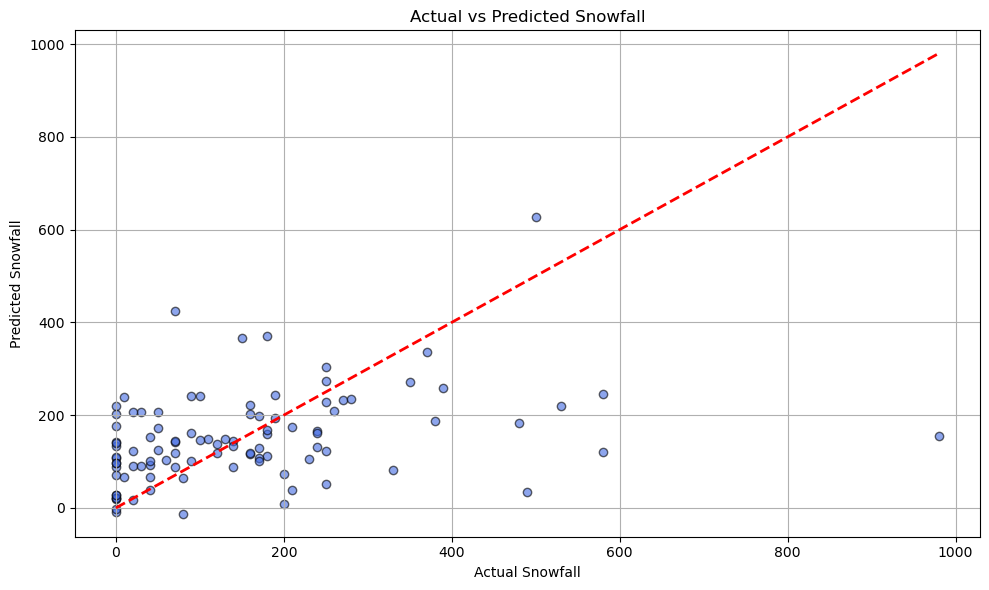

In [15]:
import matplotlib.pyplot as plt

##Plot actual vs predicted snowfall
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='royalblue', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Snowfall")
plt.ylabel("Predicted Snowfall")
plt.title("Actual vs Predicted Snowfall")
plt.grid(True)
plt.tight_layout()
plt.show()
